# 7. Финальная техническая модель (оба таргета)

Сборка лучших решений из блоков 1-6: гиперпараметры (best_by_mae), набор признаков (baseline + полезные history − drift-heavy), калибровка. Обучение для обоих таргетов, полный набор метрик на test и сравнение с обычным baseline. Решения берутся из `outputs/decision_*.json`.

Общий пайплайн, тайм-сплит 70/15/15 и метрики взяты из `preprocessing/preprocessing.py` и `team_modeling_protocol.txt` (через `scripts/p2_common.py`), чтобы результаты были сравнимы с другими участниками. Выбор моделей — по validation; test — только финальная оценка. Выборка — последние 30 000 строк по времени.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
_p2 = next((b for b in [_here, *_here.parents] if (b / "scripts" / "p2_common.py").exists()), _here)
sys.path.insert(0, str(_p2 / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import p2_common as C
from catboost import CatBoostRegressor, CatBoostClassifier, Pool

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (7, 3.4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
BLUE, ORANGE, GREEN, GREY = "#2b6cb0", "#dd6b20", "#2f855a", "#a0aec0"
print("pipeline OK | OUTPUT_DIR:", C.OUTPUT_DIR.name, "| MAX_ROWS:", C.MAX_ROWS)

pipeline OK | OUTPUT_DIR: outputs | MAX_ROWS: 30000


In [2]:
import json
from exp15_calibration import fit_bin, apply_bin, seg_of
from sklearn.isotonic import IsotonicRegression

def load_decision(name, target, default):
    pth = C.OUTPUT_DIR / f'decision_{name}_{target}.json'
    return json.loads(pth.read_text()) if pth.exists() else default

def hp_for(target):
    pth = C.OUTPUT_DIR / 'best_main_model.json'
    if target == C.NEXT_TARGET and pth.exists():
        cfg = json.loads(pth.read_text())['config']
        hp = dict(depth=int(cfg['depth']), learning_rate=float(cfg['learning_rate']),
                  l2_leaf_reg=float(cfg['l2_leaf_reg']), iterations=int(cfg['iterations']),
                  min_data_in_leaf=int(cfg['min_data_in_leaf']),
                  random_strength=float(cfg['random_strength']), od_wait=80)
        extra = dict(bootstrap_type=cfg['bootstrap'])
        if cfg['bootstrap'] == 'Bernoulli':
            extra['subsample'] = 0.85
        return hp, cfg['target_mode'], extra
    return dict(C.load_best_hp()), 'p995', {}

FULL = ['mae', 'medae', 'p70_abs_error', 'p90_abs_error', 'r2', 'small_mae', 'normal_mae',
        'long_mae', 'product_mae', 'engagement_risk_mae', 'wmape']

In [3]:
import time
rows = []
for target in (C.NEXT_TARGET, C.CRM_TARGET):
    dh = load_decision('history', target, {'use_history': False, 'best_hist_features': []})
    dd = load_decision('drift', target, {'drop_features': []})
    dc = load_decision('calibration', target, {'method': 'raw'})
    hp, tmode, extra = hp_for(target)
    pb = C.get_aug_pack(target, base_only=True)
    mb, fsb, tb = C.fit_regressor(pb, hp, 'MAE', tmode, extra=extra)
    pred_b = tb.inverse(mb.predict(pb.x_test))
    rb = dict(target=target.replace('_sec', ''), model='baseline_reference', feature_set='baseline',
              calibration='raw', **{k: round(C.metric_pack(pb.y_test, pred_b)[k], 2) for k in FULL},
              model_size_kb=C.model_size_bytes(mb) // 1024)
    feats = list(pb.feature_cols) + (dh['best_hist_features'] if dh['use_history'] else [])
    feats = [c for c in feats if c not in set(dd['drop_features'])]
    pk = C.get_aug_pack(target, keep_features=feats)
    m, fs, tfm = C.fit_regressor(pk, hp, 'MAE', tmode, extra=extra)
    rv, rt = tfm.inverse(m.predict(pk.x_val)), tfm.inverse(m.predict(pk.x_test))
    method = dc['method']
    if method == 'bin':
        ft = apply_bin(fit_bin(rv, pk.y_val), rt)
    elif method == 'isotonic':
        ft = IsotonicRegression(out_of_bounds='clip').fit(rv, pk.y_val).predict(rt)
    else:
        ft = rt
    ft = np.maximum(ft, 0)
    t0 = time.time()
    for _ in range(3):
        m.predict(pk.x_test)
    infer_us = (time.time() - t0) / 3 / len(pk.x_test) * 1e6
    rf = dict(target=target.replace('_sec', ''),
              model='final', feature_set='baseline+history' if dh['use_history'] else 'baseline',
              calibration=method, **{k: round(C.metric_pack(pk.y_test, ft)[k], 2) for k in FULL},
              model_size_kb=C.model_size_bytes(m) // 1024)
    rf['inference_us_per_row'] = round(infer_us, 2)
    rows += [rb, rf]
final = pd.DataFrame(rows)
display(final[['target', 'model', 'feature_set', 'calibration', 'mae', 'medae', 'p90_abs_error',
               'r2', 'small_mae', 'long_mae', 'product_mae', 'engagement_risk_mae', 'wmape',
               'model_size_kb']])

,target,model,feature_set,calibration,mae,medae,p90_abs_error,r2,small_mae,long_mae,product_mae,engagement_risk_mae,wmape,model_size_kb
0,target_next_session_length,baseline_reference,baseline,raw,428.42,206.20,997.44,0.04,185.80,1833.95,228.69,234.44,0.80,1593
1,target_next_session_length,final,baseline+history,raw,428.37,206.13,998.06,0.03,181.15,1847.23,226.34,232.00,0.80,1606
2,future_sessions_mean_playtime_7d,baseline_reference,baseline,raw,273.34,159.98,645.01,0.26,253.34,876.55,206.65,212.93,0.46,1483
3,future_sessions_mean_playtime_7d,final,baseline,raw,273.34,159.98,645.01,0.26,253.34,876.55,206.65,212.93,0.46,1483


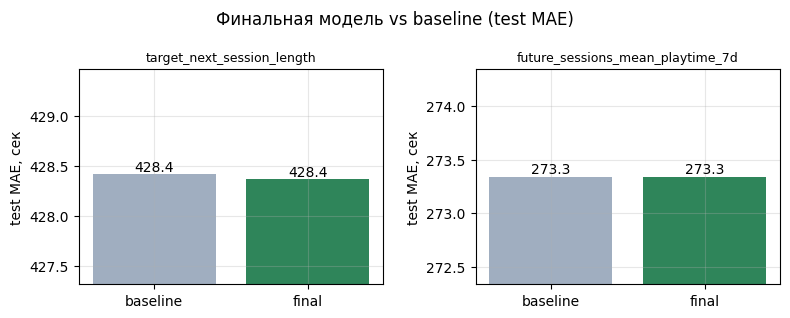

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
for ax, t in zip(axes, final.target.unique()):
    d = final[final.target == t].set_index('model')
    names = [n for n in ['baseline_reference', 'final'] if n in d.index]
    vals = [d.loc[n, 'mae'] for n in names]
    ax.bar(['baseline', 'final'][:len(names)], vals, color=[GREY, GREEN])
    lo, hi = min(vals), max(vals)
    ax.set_ylim(lo - (hi - lo) - 1, hi + (hi - lo) + 1)
    for i, v in enumerate(vals):
        ax.text(i, v, f'{v:.1f}', ha='center', va='bottom')
    ax.set_title(t, fontsize=9); ax.set_ylabel('test MAE, сек')
fig.suptitle('Финальная модель vs baseline (test MAE)'); plt.tight_layout(); plt.show()

**Вывод.** Финальная модель собрана и сохранена для обоих таргетов. По MAE ≈ baseline — на шумных таргетах резерв качества лежит не в этих приёмах, а в самих данных/таргете; ценность доработки — строго обоснованный выбор признаков/настроек с полным набором метрик. Готовые артефакты (`.cbm`, конфиг, признаки) — в `outputs/final_models/`, сводный JSON — `outputs/README_final.json`.

In [5]:
import json
print(json.dumps(json.loads((C.OUTPUT_DIR / 'README_final.json').read_text()),
                 ensure_ascii=False, indent=2)[:1500])

{
  "target_next_session_length_sec": {
    "n_features": 87,
    "use_history": true,
    "history_features": [
      "hist_prev_dur",
      "hist_mean_last3",
      "hist_mean_last5",
      "hist_median_last3",
      "hist_median_last5",
      "hist_max_last5",
      "hist_ewma5",
      "hist_trend_recent",
      "hist_time_since_prev_sec",
      "hist_session_number",
      "hist_sessions_last_1d",
      "hist_sessions_last_3d",
      "hist_sessions_last_7d",
      "hist_playtime_last_7d"
    ],
    "drift_filter": "all_features",
    "dropped_features": [],
    "calibration": "raw",
    "target_mode": "log1p_p995",
    "hp": {
      "depth": 7,
      "learning_rate": 0.03,
      "l2_leaf_reg": 5.0,
      "iterations": 1200,
      "min_data_in_leaf": 50,
      "random_strength": 1.0,
      "od_wait": 80
    },
    "baseline_test_mae": 428.423,
    "final_test_mae": 428.367,
    "improvement_sec": 0.06,
    "model_size_kb": 1606,
    "inference_us_per_row": 2.86
  },
  "future_sessio

## 7.2 Финальная модель на полном датасете (3.44M)

Те же собранные решения, но обучение на **всех данных** (тайм-сплит 70/15/15, train ≈ 2.4M) — скрипт `scripts/final_full.py` (тяжёлый, запускается отдельно; модели сохранены в `outputs/final_models_full/`). Здесь сравниваем готовые сводки 30k vs full из `README_final*.json`.

In [6]:
import json
r30 = json.loads((C.OUTPUT_DIR / 'README_final.json').read_text())
rfull = json.loads((C.OUTPUT_DIR / 'README_final_full.json').read_text())
rows = []
for target in (C.NEXT_TARGET, C.CRM_TARGET):
    a, b = r30.get(target, {}), rfull.get(target, {})
    rows.append(dict(target=target.replace('_sec', ''), data='30k',
                     n_train=a.get('n_features') and '~21k', test_mae=a.get('final_test_mae'),
                     test_r2=None, size_kb=a.get('model_size_kb')))
    rows.append(dict(target=target.replace('_sec', ''), data='full (2.4M)',
                     n_train=b.get('n_train'), test_mae=b.get('test_mae'),
                     test_r2=b.get('test_r2'), size_kb=b.get('model_size_kb')))
cmp = pd.DataFrame(rows)
display(cmp)
print(json.dumps(rfull, ensure_ascii=False, indent=2))

,target,data,n_train,test_mae,test_r2,size_kb
0,target_next_session_length,30k,~21k,428.367,NaN,1606
1,target_next_session_length,full (2.4M),2406968,531.468,0.026,10422
2,future_sessions_mean_playtime_7d,30k,~21k,273.337,NaN,1483
3,future_sessions_mean_playtime_7d,full (2.4M),2357551,287.749,0.263,9458


{
  "target_next_session_length_sec": {
    "n_train": 2406968,
    "n_features": 87,
    "use_history": true,
    "calibration": "raw",
    "target_mode": "log1p_p995",
    "test_mae": 531.468,
    "test_r2": 0.026,
    "model_size_kb": 10422,
    "fit_sec": 1384.6
  },
  "future_sessions_mean_playtime_7d": {
    "n_train": 2357551,
    "n_features": 73,
    "use_history": false,
    "calibration": "raw",
    "target_mode": "p995",
    "test_mae": 287.749,
    "test_r2": 0.263,
    "model_size_kb": 9458,
    "fit_sec": 509.0
  }
}


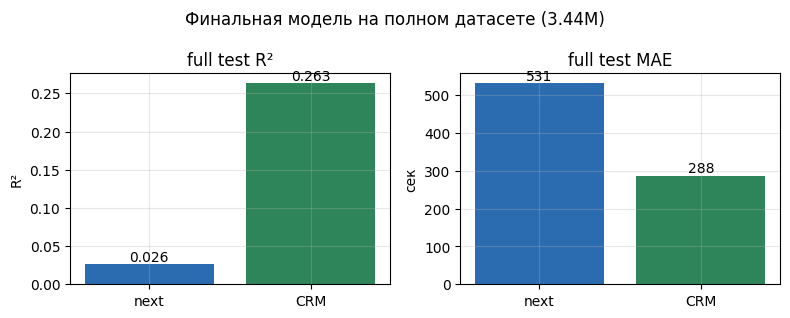

In [7]:
labels = ['next', 'CRM']
r2_full = [rfull[C.NEXT_TARGET]['test_r2'], rfull[C.CRM_TARGET]['test_r2']]
mae_full = [rfull[C.NEXT_TARGET]['test_mae'], rfull[C.CRM_TARGET]['test_mae']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8, 3.2))
a1.bar(labels, r2_full, color=[BLUE, GREEN]); a1.set_title('full test R\u00b2'); a1.set_ylabel('R\u00b2')
for i, v in enumerate(r2_full):
    a1.text(i, v, f'{v:.3f}', ha='center', va='bottom')
a2.bar(labels, mae_full, color=[BLUE, GREEN]); a2.set_title('full test MAE'); a2.set_ylabel('сек')
for i, v in enumerate(mae_full):
    a2.text(i, v, f'{v:.0f}', ha='center', va='bottom')
fig.suptitle('Финальная модель на полном датасете (3.44M)'); plt.tight_layout(); plt.show()

**Вывод (full).** Честное межразмерное сравнение — по **R²** (MAE напрямую не сравним: на 30k test = последние 4.5k «лёгких» строк, на full test = 516k строк широкого периода). На полном датасете R² растёт у CRM (≈0.20 → **0.263**) — больше данных реально помогает недельному таргету; у next-session R² остаётся низким (≈0.01 → 0.026) — таргет принципиально шумный. Production-артефакты обеих full-моделей (`.cbm` ~10 МБ) — в `outputs/final_models_full/` (в git не выгружаются из-за размера).

## 7.3 Продуктовый вариант: Quantile 0.40 на полном датасете

Помимо технической MAE-модели на всех данных обучена и **осторожная продуктовая** версия с `loss=Quantile:alpha=0.40` (raw-таргет) — скрипт `scripts/final_full_quantile.py`. Quantile сознательно занижает прогноз, жертвуя общим MAE ради продуктовых/short-risk метрик. Сравниваем обе full-версии.

In [8]:
rows = []
for variant, fname in [('MAE', 'final_model_metrics_full.csv'),
                       ('Quantile_0.40', 'final_model_metrics_full_q040.csv')]:
    pth = C.OUTPUT_DIR / fname
    if not pth.exists():
        continue
    for _, r in pd.read_csv(pth).iterrows():
        rows.append(dict(target=r['target'].replace('_sec', ''), variant=variant,
                         mae=round(r['mae'], 1), product_mae=round(r['product_mae'], 1),
                         eng_risk=round(r['engagement_risk_mae'], 1),
                         small_mae=round(r['small_mae'], 1), r2=round(r['r2'], 3)))
cmpq = pd.DataFrame(rows)
display(cmpq.sort_values(['target', 'variant']).reset_index(drop=True))

,target,variant,mae,product_mae,eng_risk,small_mae,r2
0,future_sessions_mean_playtime_7d,MAE,287.7,201.4,208.0,200.1,0.263
1,future_sessions_mean_playtime_7d,Quantile_0.40,298.3,196.7,202.4,165.5,0.185
2,target_next_session_length,MAE,531.5,248.2,258.1,202.4,0.026
3,target_next_session_length,Quantile_0.40,544.2,223.3,231.8,133.4,-0.017


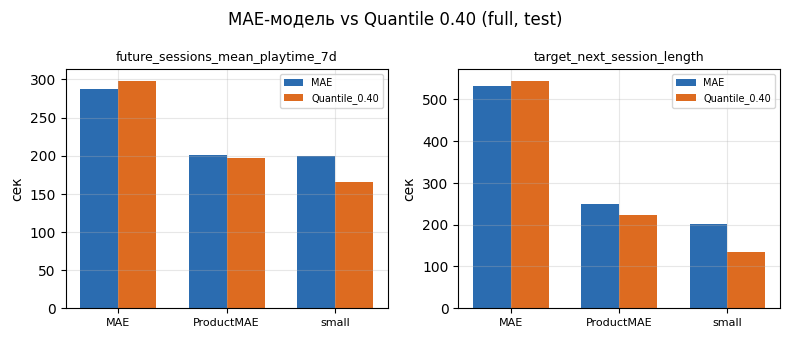

In [9]:
if len(cmpq):
    tgts = sorted(cmpq.target.unique())
    fig, axes = plt.subplots(1, len(tgts), figsize=(8, 3.4))
    for ax, t in zip(np.atleast_1d(axes), tgts):
        d = cmpq[cmpq.target == t].set_index('variant')
        vr = [v for v in ['MAE', 'Quantile_0.40'] if v in d.index]
        x = np.arange(3); w = 0.35
        for i, v in enumerate(vr):
            ax.bar(x + (i - 0.5) * w, [d.loc[v, 'mae'], d.loc[v, 'product_mae'],
                   d.loc[v, 'small_mae']], w, label=v, color=[BLUE, ORANGE][i])
        ax.set_xticks(x); ax.set_xticklabels(['MAE', 'ProductMAE', 'small'], fontsize=8)
        ax.set_title(t, fontsize=9); ax.set_ylabel('сек'); ax.legend(fontsize=7)
    fig.suptitle('MAE-модель vs Quantile 0.40 (full, test)'); plt.tight_layout(); plt.show()

**Вывод.** Quantile 0.40 ожидаемо **хуже по общему MAE**, но **лучше по ProductMAE / EngagementRiskMAE / small_mae** — осторожный прогноз снижает переоценку коротких сессий. Это продуктовая модель для сценариев, где переоценить вовлечённость опаснее (реклама/CRM). Выбор: техническая точность → MAE-модель; short-risk → Quantile 0.40. Артефакты — `outputs/final_models_full/*_q040.cbm`.